<a href="https://colab.research.google.com/github/priyaakridhaa/fdp_day1_ml/blob/day1/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch   # PyTorch — our deep-learning toolkit (already installed in Colab)

# Is a GPU available?
print("GPU available:", torch.cuda.is_available())

# We'll send our work to the GPU if there is one, otherwise the CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

GPU available: True
Using device: cuda


# New section

In [ ]:
import torch

a = torch.tensor(7)                       # a single number (scalar)
b = torch.tensor([1.0, 2.0, 3.0])         # a list (vector)
c = torch.tensor([[1.0, 2.0], [3.0, 4.0]]) # a 2x2 grid (matrix)

print("a:", a, "| shape:", a.shape)       # shape: torch.Size([])  -> just one number
print("b:", b, "| shape:", b.shape)       # shape: torch.Size([3]) -> 3 numbers in a row
print("c:\n", c, "| shape:", c.shape)     # shape: torch.Size([2, 2]) -> 2 rows, 2 columns

a: tensor(7) | shape: torch.Size([])
b: tensor([1., 2., 3.]) | shape: torch.Size([3])
c:
 tensor([[1., 2.],
        [3., 4.]]) | shape: torch.Size([2, 2])


In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])

print("Add:     ", x + y)        # [11, 22, 33] — element by element
print("Multiply:", x * y)        # [10, 40, 90]
print("Sum of x:", x.sum())      # 6.0

Add:      tensor([11., 22., 33.])
Multiply: tensor([10., 40., 90.])
Sum of x: tensor(6.)


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch

# Load the flowers
iris = load_iris()
X = iris.data         # 150 flowers x 4 measurements
y = iris.target       # the species: 0, 1, or 2

print("Inputs shape:", X.shape)    # (150, 4) -> 150 flowers, 4 numbers each
print("First flower:", X[0], "-> species", y[0])

# Split into train / test (same idea as Day 1: hide some data to grade honestly)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Turn the data into tensors and send to our device (GPU/CPU)
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.long).to(device)

print("Ready: training on", X_train.shape[0], "flowers")

Inputs shape: (150, 4)
First flower: [5.1 3.5 1.4 0.2] -> species 0
Ready: training on 120 flowers


In [ ]:
import torch.nn as nn

# Define the network as a class. Think of it as a recipe for the layers.
class FlowerNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: 4 inputs -> 16 hidden neurons
        self.layer1 = nn.Linear(4, 16)
        # The "squish" function that lets the network learn curves, not just lines
        self.relu = nn.ReLU()
        # Layer 2: 16 hidden neurons -> 3 outputs (one score per species)
        self.layer2 = nn.Linear(16, 3)

    # forward() describes how data flows through the layers
    def forward(self, x):
        x = self.layer1(x)   # multiply + add
        x = self.relu(x)     # squish
        x = self.layer2(x)   # multiply + add -> 3 scores
        return x

# Create the network and send it to the GPU/CPU
model = FlowerNet().to(device)
print(model)

FlowerNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)


In [ ]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)   # lr = step size

# Train for 100 rounds (each round = one full taste-test loop over the data)
for epoch in range(10):
    # 1. GUESS — predict scores for every training flower
    predictions = model(X_train)

    # 2. CHECK — how wrong were we?
    loss = loss_function(predictions, y_train)

    # 3. ADJUST — clear old gradients, find new ones, take a downhill step
    optimizer.zero_grad()   # reset the slope tracker
    loss.backward()         # autograd works out which way is downhill
    optimizer.step()        # nudge every weight that way

    # Print progress every 20 rounds
    if (epoch + 1) % 20 == 0:
        print(f"Round {epoch+1:3d} | error (loss): {loss.item():.3f}")

In [ ]:
# Turn off learning for testing (we're just checking, not adjusting)
model.eval()
with torch.no_grad():                      # don't track gradients — faster
    test_scores = model(X_test)            # 3 scores per flower
    predicted = test_scores.argmax(dim=1)  # pick the species with the highest score
    accuracy = (predicted == y_test).float().mean()

print(f"Test accuracy: {accuracy.item()*100:.1f}%")   # usually ~95-100%

Test accuracy: 66.7%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# Upload stock.csv in Colab
df = pd.read_csv('/content/stock.csv')

df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,01-01-2020,101.764052,100.160928,99.494642,99.909756,101.761266
1,02-01-2020,102.171269,99.969968,98.682973,100.640755,102.528643
2,03-01-2020,103.171258,99.575237,98.182139,100.574847,101.887811
3,04-01-2020,105.483215,99.308641,97.149381,100.925017,101.490049
4,05-01-2020,107.453175,98.188428,99.575396,101.594411,101.604283


In [ ]:
data = df[['Close']]

KeyError: "None of [Index(['Close'], dtype='object')] are in the [columns]"

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

NameError: name 'data' is not defined

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('/content/stock.csv')

# Select feature and target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Normalize features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Deep Learning Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=100, batch_size=32)

# Predict
predictions = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

# Show predictions
result = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': predictions.flatten()
})

print(result.head(10))

KeyError: "None of [Index(['Open', 'High', 'Low', 'Volume'], dtype='object')] are in the [columns]"

In [ ]:
import pandas as pd

df = pd.read_csv('/content/stock.csv')

print(df.columns)

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')


In [ ]:
print(df.head())

   Unnamed: 0     Stock_1     Stock_2    Stock_3     Stock_4     Stock_5
0  01-01-2020  101.764052  100.160928  99.494642   99.909756  101.761266
1  02-01-2020  102.171269   99.969968  98.682973  100.640755  102.528643
2  03-01-2020  103.171258   99.575237  98.182139  100.574847  101.887811
3  04-01-2020  105.483215   99.308641  97.149381  100.925017  101.490049
4  05-01-2020  107.453175   98.188428  99.575396  101.594411  101.604283


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('/content/stock.csv')

# Select feature and target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Normalize features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Deep Learning Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=100, batch_size=32)

# Predict
predictions = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

# Show predictions
result = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': predictions.flatten()
})

print(result.head(10))

KeyError: "None of [Index(['Open', 'High', 'Low', 'Volume'], dtype='object')] are in the [columns]"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Load dataset
df = pd.read_csv('/content/stock.csv')

# Remove date column
df = df.drop(columns=['Unnamed: 0'])

# Predict Stock_1 using other stocks
X = df[['Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']]
y = df['Stock_1']

# Normalize features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Deep Learning Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Adam optimizer with learning rate = 0.1
optimizer = Adam(learning_rate=0.1)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# Train model for 100 epochs
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Prediction
predictions = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

# Display first 10 predictions
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

print(result.head(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 4670.9165 - mae: 61.7534 - val_loss: 653.7297 - val_mae: 24.4457
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 746.0797 - mae: 23.6978 - val_loss: 421.1504 - val_mae: 19.0491
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 348.8703 - mae: 15.7638 - val_loss: 285.2357 - val_mae: 15.2290
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 206.0868 - mae: 11.7085 - val_loss: 165.8234 - val_mae: 11.2326
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 151.0315 - mae: 10.1659 - val_loss: 72.5546 - val_mae: 7.4059
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 104.9731 - mae: 8.4429 - val_loss: 133.4158 - val_mae: 9.1055
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 138.1195 - mae: 9.7023 - val_loss: 68.3995 - val_mae: 6.1627
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 89.2698 - mae: 7.6340 - val_loss: 61.5381 - val_mae: 6.8856
Epoch 9/100
10/10 ━━

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2 Score:", r2)

MSE : 87.56412902912508
RMSE: 9.357570679889363
MAE : 8.014916736331076
R2 Score: -0.823593951751804


In [ ]:
mape = np.mean(np.abs((y_test - predictions.flatten()) / y_test)) * 100
accuracy = 100 - mape

print("MAPE:", mape)
print("Prediction Accuracy:", accuracy, "%")

MAPE: 7.386508196257023
Prediction Accuracy: 92.61349180374297 %


In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# A recipe to turn each image into a tensor of pixel numbers
to_tensor = transforms.ToTensor()

# Download MNIST (Colab fetches it automatically)
train_data = datasets.MNIST(root="data", train=True,  download=True, transform=to_tensor)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=to_tensor)

print("Training images:", len(train_data))   # 60000
print("One image shape:", train_data[0][0].shape)  # [1, 28, 28] -> 1 colour, 28x28 pixels
print("Its label:", train_data[0][1])         # the digit it shows

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Training images: 60000
One image shape: torch.Size([1, 28, 28])
Its label: 5


In [2]:
# DataLoader serves the data in shuffled batches of 64
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Peek at one batch
images, labels = next(iter(train_loader))
print("One batch of images:", images.shape)   # [64, 1, 28, 28] -> 64 images at once
print("One batch of labels:", labels.shape)   # [64]

One batch of images: torch.Size([64, 1, 28, 28])
One batch of labels: torch.Size([64])


In [4]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # turn 28x28 image into a row of 784 numbers
        self.layer1 = nn.Linear(784, 128)     # 784 pixels -> 128 hidden neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)        # randomly ignore 20% of neurons while training
        self.layer2 = nn.Linear(128, 10)      # 128 -> 10 outputs (one per digit 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x


print(model)

NameError: name 'model' is not defined

In [ ]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # turn 28x28 image into a row of 784 numbers
        self.layer1 = nn.Linear(784, 128)     # 784 pixels -> 128 hidden neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)        # randomly ignore 20% of neurons while training
        self.layer2 = nn.Linear(128, 10)      # 128 -> 10 outputs (one per digit 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

model = DigitNet().to(device)
print(model)

In [5]:
import torch

# Device setup for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # turn 28x28 image into a row of 784 numbers
        self.layer1 = nn.Linear(784, 128)     # 784 pixels -> 128 hidden neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)        # randomly ignore 20% of neurons while training
        self.layer2 = nn.Linear(128, 10)      # 128 -> 10 outputs (one per digit 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

model = DigitNet().to(device)
print(model)

DigitNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()   # tell the network we're training (dropout ON)

for epoch in range(3):                       # 3 full passes is plenty for MNIST
    running_loss = 0.0
    for images, labels in train_loader:      # one batch at a time
        images, labels = images.to(device), labels.to(device)

        # The same taste-test loop, per batch:
        predictions = model(images)               # 1. guess
        loss = loss_function(predictions, labels) # 2. check
        optimizer.zero_grad()                     # 3a. reset slopes
        loss.backward()                           # 3b. find downhill direction
        optimizer.step()                          # 3c. nudge the weights

        running_loss += loss.item()

    avg = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} | average error: {avg:.3f}")

Epoch 1 | average error: 0.373
Epoch 2 | average error: 0.178
Epoch 3 | average error: 0.132


In [8]:
model.eval()    # dropout OFF for testing
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted = model(images).argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")   # usually ~97%

Test accuracy: 96.93%


In [9]:
model.eval()    # dropout OFF for testing
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted = model(images).argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")   # usually ~97%

Test accuracy: 96.93%


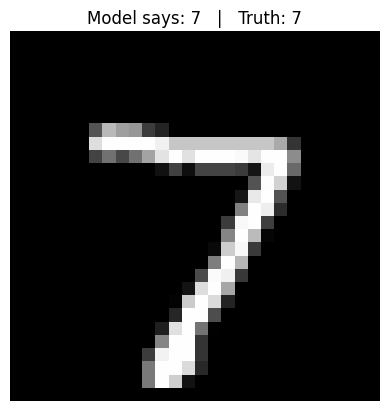

In [10]:
import matplotlib.pyplot as plt

# Grab one test image
img, true_label = test_data[0]
model.eval()
with torch.no_grad():
    guess = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Model says: {guess}   |   Truth: {true_label}")
plt.axis("off")
plt.show()